# A. DATA PRE-PROCESSING


1.   Data Merging
2.   Case Folding
3.   Removal of Irrelevant Character
4.   Filtering
5.   Stemming
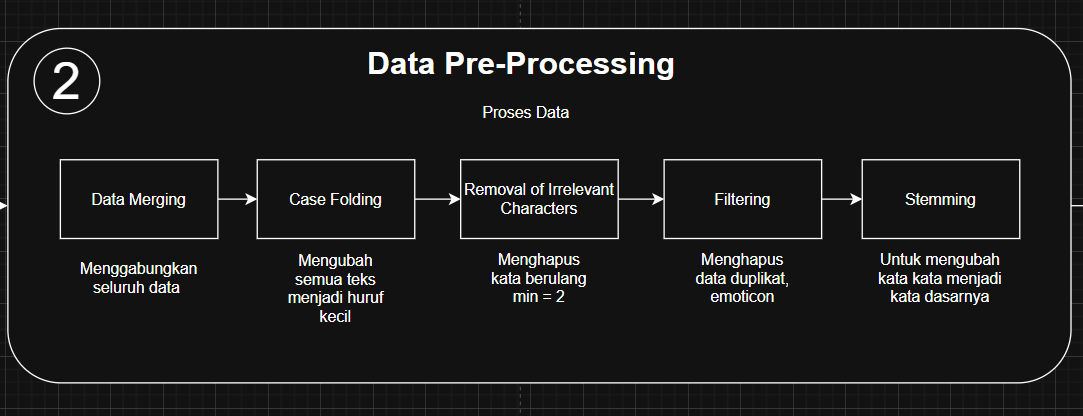


In [2]:
import numpy as np
import pandas as pd
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from google.colab import files

# Install lime if not already installed
try:
    from lime.lime_text import LimeTextExplainer
except ModuleNotFoundError:
    !pip install lime
    from lime.lime_text import LimeTextExplainer

ModuleNotFoundError: No module named 'lime'

In [8]:
# Data Merging - Menggabungkan data dari berbagai sumber data

# Inisialisasi Variabel Penampung Raw Text / Text Mentah
raw_text = files.upload()



Saving dictionaryKasar.csv to dictionaryKasar (1).csv


# 2. Removal of Irrevant & Case Folding -> Case Folding


In [9]:
# Split menjadi baris, Menghapus Whitespace, dan Filter String Kosong
# raw_text is a dictionary, extract the content of the uploaded file

# Assuming only one file was uploaded and we want to process its content
if raw_text:
    file_name = list(raw_text.keys())[0]
    file_content_bytes = raw_text[file_name]
    # Decode bytes to string assuming 'utf-8' encoding
    file_content_string = file_content_bytes.decode('utf-8')
    word_list = [line.strip() for line in file_content_string.splitlines() if line.strip()]
else:
    word_list = []

# Print hasil untuk validasi
print("===== MENGEKSTRAK DATA =====")
print("HASIL :")
print(word_list)

===== MENGEKSTRAK DATA =====
HASIL :
['abbo', 'abo', 'abortion', 'abuse', 'addict', 'addicts', 'adult', 'africa', 'african', 'alla', 'allah', 'alligatorbait', 'amateur', 'american', 'anal', 'analannie', 'analsex', 'angie', 'angry', 'anus', 'arab', 'arabs', 'areola', 'argie', 'aroused', 'arse', 'arsehole', 'asian', 'ass', 'assassin', 'assassinate', 'assassination', 'assault', 'assbagger', 'assblaster', 'assclown', 'asscowboy', 'asses', 'assfuck', 'assfucker', 'asshat', 'asshole', 'assholes', 'asshore', 'assjockey', 'asskiss', 'asskisser', 'assklown', 'asslick', 'asslicker', 'asslover', 'assman', 'assmonkey', 'assmunch', 'assmuncher', 'asspacker', 'asspirate', 'asspuppies', 'assranger', 'asswhore', 'asswipe', 'athletesfoot', 'attack', 'australian', 'babe', 'babies', 'backdoor', 'backdoorman', 'backseat', 'badfuck', 'balllicker', 'balls', 'ballsack', 'banging', 'baptist', 'barelylegal', 'barf', 'barface', 'barfface', 'bast', 'bastard', 'bazongas', 'bazooms', 'beaner', 'beast', 'beastality

In [10]:
# Buat list untuk kata-kata yang sudah dibersihkan
cleaned_words = []

for word in word_list:
  cleaned = re.sub(r'[^a-zA-Z\s]', '', word)  # Remove character yang bukan huruf
  # Ubah jadi Lowercase
  cleaned = cleaned.lower().strip()
  # Filter empty strings
  if cleaned:
     cleaned_words.append(cleaned)

# Print hasil untuk validasi
print("===== MEMBERSIHKAN DATA =====")
print("HASIL :")
print(cleaned_words)

===== MEMBERSIHKAN DATA =====
HASIL :
['abbo', 'abo', 'abortion', 'abuse', 'addict', 'addicts', 'adult', 'africa', 'african', 'alla', 'allah', 'alligatorbait', 'amateur', 'american', 'anal', 'analannie', 'analsex', 'angie', 'angry', 'anus', 'arab', 'arabs', 'areola', 'argie', 'aroused', 'arse', 'arsehole', 'asian', 'ass', 'assassin', 'assassinate', 'assassination', 'assault', 'assbagger', 'assblaster', 'assclown', 'asscowboy', 'asses', 'assfuck', 'assfucker', 'asshat', 'asshole', 'assholes', 'asshore', 'assjockey', 'asskiss', 'asskisser', 'assklown', 'asslick', 'asslicker', 'asslover', 'assman', 'assmonkey', 'assmunch', 'assmuncher', 'asspacker', 'asspirate', 'asspuppies', 'assranger', 'asswhore', 'asswipe', 'athletesfoot', 'attack', 'australian', 'babe', 'babies', 'backdoor', 'backdoorman', 'backseat', 'badfuck', 'balllicker', 'balls', 'ballsack', 'banging', 'baptist', 'barelylegal', 'barf', 'barface', 'barfface', 'bast', 'bastard', 'bazongas', 'bazooms', 'beaner', 'beast', 'beastalit

In [ ]:
# Data Visualization

In [11]:
# Frequency Analysis

from collections import Counter

cleaned_words = list(set(cleaned_words))

# Menghitung Frekuensi
word_freq = Counter(cleaned_words)

top_20_terms = word_freq.most_common(20)

print("==== Top 20 Most Frequent Terms ====")
print(f"Total unique words: {len(cleaned_words)}\n")

for word, count in top_20_terms:
  print(f"{word:<20} : {count}")

==== Top 20 Most Frequent Terms ====
Total unique words: 1872

cyberslimer          : 1
titlicker            : 1
dirty pillows        : 1
bugil                : 1
liberal              : 1
ecchi                : 1
fook                 : 1
uk                   : 1
african              : 1
lesbin               : 1
sex                  : 1
pissin               : 1
shiting              : 1
titbitnipply         : 1
wetb                 : 1
raghead              : 1
pthc                 : 1
naked                : 1
gyppie               : 1
crotch               : 1


# B. FEATURE ENGINEERING - SOON


1.   Slang & Abbreviation Normalization
2.   Code-Mixed Tokenization
3.   Lexicon-Based Auxiliary Feature
4.   CLS Embedding 768 dim dari BERT
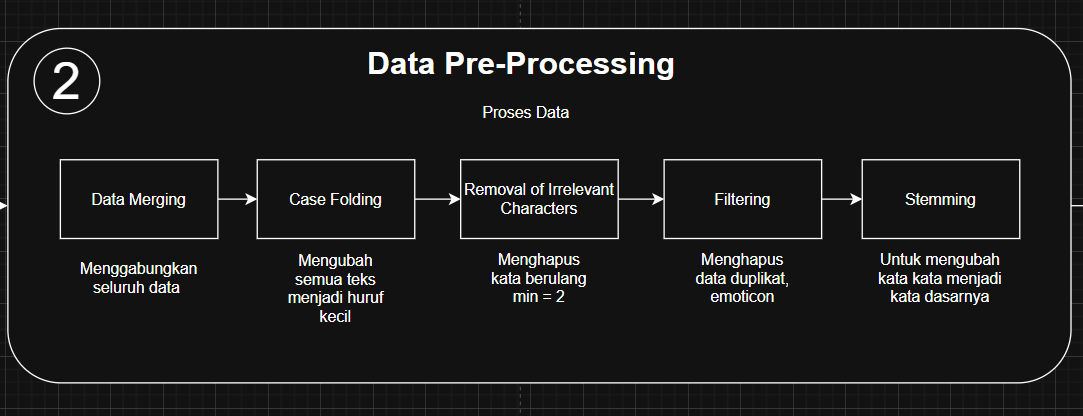


In [ ]:
# Slang & Abbreviation Normalization

In [12]:

sentenceDataCSV = files.upload()

sentenceDataRaw = {}
for fileCSV in sentenceDataCSV.keys():
	# Specify header=None to treat the first row as data, not header
	sentenceDataRaw[fileCSV] = pd.read_csv(fileCSV, header=None)
print("HASIL:")
print(sentenceDataRaw)

Saving dataEnglish.csv to dataEnglish.csv
Saving dataIndo.csv to dataIndo.csv
HASIL:
{'dataEnglish.csv':                                                      0
0    Law enforcement is not trained to shoot to app...
1    Dont you reckon them 'black lives matter' bann...
2    here people his facebook is https://www.facebo...
3    Check out this you tube post. "Black man goes ...
4    I would LOVE to see this pussy go to Staten Is...
..                                                 ...
457                                       Thanks Obama
458  0:05 to 0:18 I had no idea cops mooed, I alway...
459                      9:41 Dems a big ass gun! ????
460  Whites should move-out of Ferguson, let's see ...
461  Stats don`t represent the problem. Race baitin...

[462 rows x 1 columns], 'dataIndo.csv':                                                      0
0    bukan hanya spanduk prof video orasi mereka bu...
1    gy sange gatel yh tetek memeky drnjng tempat t...
2    pertama kali denger lagu

In [13]:


cleaned_sentences = []

for df in sentenceDataRaw.values():          # loop over each DataFrame
    # Access the first column by its integer index (0) as there's no header
    for sentence in df[0]:

        cleaned = re.sub(r'[^a-zA-Z\s]', '', str(sentence))
        cleaned = re.sub(r'\s+', ' ', cleaned).strip()
        cleaned = cleaned.lower()

        if cleaned:
            cleaned_sentences.append(cleaned)

cleaned_text = "\n".join(cleaned_sentences)

print(cleaned_text)

law enforcement is not trained to shoot to apprehend they are trained to shoot to kill and i thank wilson for killing that punk bitch
dont you reckon them black lives matter banners being held by white cunts is kinda patronizing and ironically racist could they have not come up with somethin better or is it just what white folks do to give them selves pride ooo look at me im being nice for the black people why does it always have to be about race actually the whole world is pussyfootin around for fear of being racist its fuckin daft man
here people his facebook is httpswwwfacebookcombassemmasri he has ties with isis and other terrorist groups he is a muslim extremist
check out this you tube post black man goes on an epic rant against ferguson rioters although his message is delivered with childish cartoonish emotions he is one of the very few african americans who gets it
i would love to see this pussy go to staten island and spit on a cop i would love to see it happen mike brown was a

In [14]:
def tokenize(text):
    # Memastikan string dan lowercase
    text = str(text).lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

def corpusLookup(df, text_column, corpus):

    corpus_set = set(word.lower() for word in corpus)

    corpusCounts = []
    corpusBinary = []
    corpusRatio = []

    for text in df[text_column]:
        tokens = tokenize(text)

        count = sum(1 for token in tokens if token in corpus_set)
        total_tokens = len(tokens)

        ratio = count / total_tokens if total_tokens > 0 else 0

        corpusCounts.append(count)
        corpusBinary.append(1 if count > 0 else 0)
        corpusRatio.append(ratio)

    df[f'{text_column}_corpus_count'] = corpusCounts
    df[f'{text_column}_corpus_binary'] = corpusBinary
    df[f'{text_column}_corpus_ratio'] = corpusRatio

    return df

def main(cleaned_words_param, cleaned_sentences_param):
    corpus = cleaned_words_param
    corpus_set = set(word.lower() for word in corpus)
    total_count = 0
    sentence_counts = []
    all_found_words = [] # New list to store all found bad words

    print("\n===== HASIL PER KALIMAT =====")

    for sentence in cleaned_sentences_param:
        tokens = sentence.split()
        found_words = [token for token in tokens if token in corpus_set]
        count = len(found_words)
        total_count += count
        sentence_counts.append(count)
        all_found_words.extend(found_words) # Add found words to the list

        print(f"Kalimat: {sentence}")
        print(f"Jumlah kata corpus ditemukan: {count}")
        if found_words:
            print(f"Kata-kata yang ditemukan: {', '.join(found_words)}\n")
        else:
            print("Tidak ada kata corpus ditemukan.\n")

    from collections import Counter
    bad_word_frequencies = Counter(all_found_words)

    print("===== RINGKASAN ====")
    print("Total kemunculan kata corpus:", total_count)
    print("Count per kalimat:", sentence_counts)
    print("\n===== FREKUENSI KATA KASAR YANG DITEMUKAN ====")
    if bad_word_frequencies:
        for word, freq in bad_word_frequencies.most_common():
            print(f"{word}: {freq}")
    else:
        print("Tidak ada kata kasar dari corpus yang ditemukan di kalimat.")

    return bad_word_frequencies # Return the Counter object


if __name__ == "__main__":
    # Assign the returned Counter object to a global variable
    found_bad_word_frequencies = main(cleaned_words, cleaned_sentences)


===== HASIL PER KALIMAT =====
Kalimat: law enforcement is not trained to shoot to apprehend they are trained to shoot to kill and i thank wilson for killing that punk bitch
Jumlah kata corpus ditemukan: 5
Kata-kata yang ditemukan: shoot, shoot, kill, killing, bitch

Kalimat: dont you reckon them black lives matter banners being held by white cunts is kinda patronizing and ironically racist could they have not come up with somethin better or is it just what white folks do to give them selves pride ooo look at me im being nice for the black people why does it always have to be about race actually the whole world is pussyfootin around for fear of being racist its fuckin daft man
Jumlah kata corpus ditemukan: 6
Kata-kata yang ditemukan: black, racist, black, fear, racist, fuckin

Kalimat: here people his facebook is httpswwwfacebookcombassemmasri he has ties with isis and other terrorist groups he is a muslim extremist
Jumlah kata corpus ditemukan: 2
Kata-kata yang ditemukan: terrorist, m

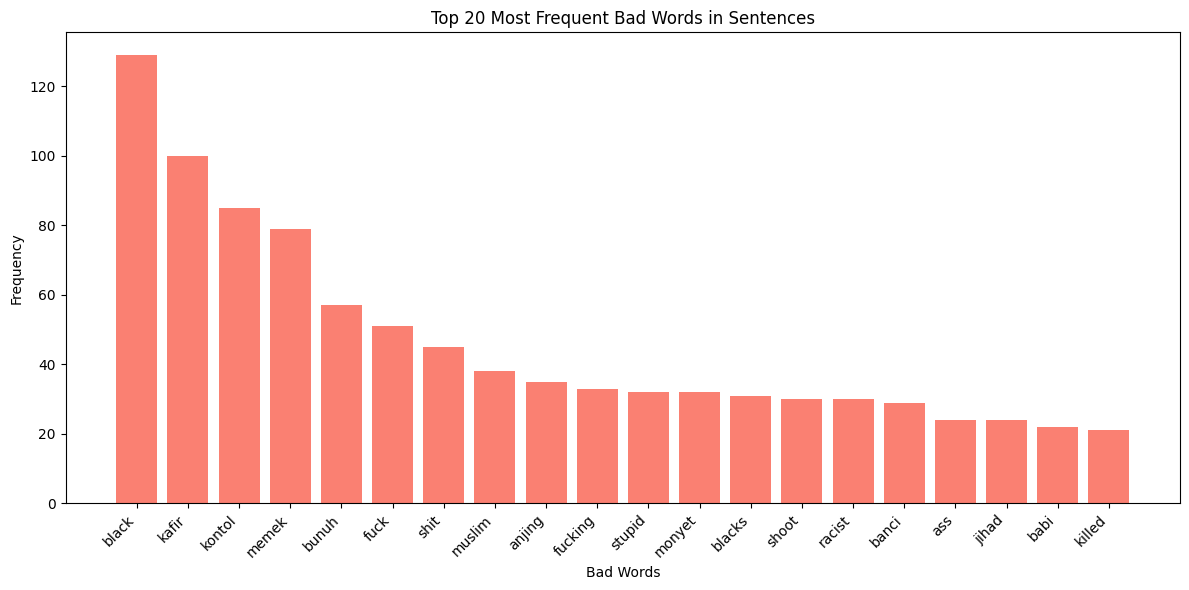

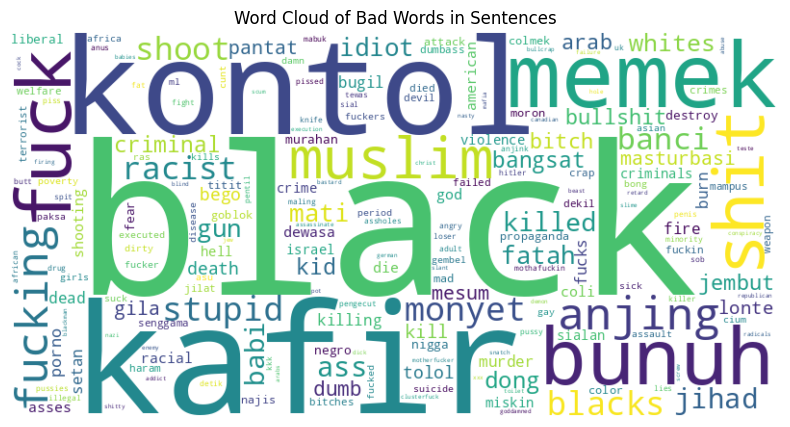

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Prepare data for the bar chart using the frequencies of found bad words
# We'll take the top 20 most frequent bad words
if 'found_bad_word_frequencies' in globals() and found_bad_word_frequencies:
    top_20_bad_words = found_bad_word_frequencies.most_common(20)
    labels = [word for word, count in top_20_bad_words]
    values = [count for word, count in top_20_bad_words]

    # Create the bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(labels, values, color='salmon')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 20 Most Frequent Bad Words in Sentences')
    plt.xlabel('Bad Words')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("No bad words found in sentences for bar chart visualization.")


# Create the word cloud using all found bad words
if 'found_bad_word_frequencies' in globals() and found_bad_word_frequencies:
    # Generate word cloud directly from frequency dictionary, using 'viridis' colormap for better visibility
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(found_bad_word_frequencies)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Bad Words in Sentences')
    plt.show()
else:
    print("No bad words found in sentences for word cloud visualization.")